In [1]:
"""IMPORT PACKAGES"""
import numpy as np
import neuralfoil as nf
import scipy.optimize
import pandas as pd
import os
import matplotlib.pyplot as plt
import itertools
import aerosandbox as asb
from joblib import Parallel, delayed

from Blade import Blade
from APCReader import APCReader
from Airfoil_Section import Airfoil_Section

In [2]:
"""DEFINE GLOBAL PROPELLER PARAMETERS"""
class PropellerParameters:
    def __init__(self, prop_radius, hub_radius, n_blades, RPM, v_inf, a_inf, rho, mu):
        self.prop_radius = prop_radius
        self.prop_diameter = 2*prop_radius
        self.hub_radius = hub_radius
        self.n_blades = n_blades
        self.RPM = RPM
        self.omega = 2 * np.pi * RPM / 60
        
        self.v_inf = v_inf
        self.a_inf = a_inf
        self.rho = rho
        self.mu = mu
        
    def __repr__(self):
        return (f"PropellerParameters(prop_diameter={self.prop_diameter}, hub_radius={self.hub_radius}, "
                f"n_blades={self.n_blades}, RPM={self.RPM}, v_inf={self.v_inf}, rho={self.rho}, mu={self.mu})")

In [3]:
"""SOLVE BEMT FOR EACH SECTION"""
class SectionForces:
    def __init__(self, airfoil_coordinates, r, dr, chord, theta, propeller_params):
        self.airfoil_coordinates = airfoil_coordinates
        self.r = r
        self.dr = dr
        self.chord = chord
        self.theta = theta
        self.propeller_params = propeller_params
        self.Re = 1e6  #Initial guess for Reynolds number
        self.Ma = 0.05 #Initial guess for Mach number

    @property
    def sigma(self):
        return self.propeller_params.n_blades * self.chord / (2 * np.pi * self.r)

    def prandtl_loss(self, phi):
        def prandtl(d_r, r, phi):
            f = self.propeller_params.n_blades * d_r / (2 * r * np.sin(phi))
            return 1.0 if -f > 500 else 2 * np.arccos(min(1.0, np.exp(-f))) / np.pi

        if phi == 0:
            return 1.0
        Ftip = prandtl(self.propeller_params.prop_radius - self.r, self.r, phi)
        Fhub = prandtl(self.r - self.propeller_params.hub_radius, self.r, phi)
        return Ftip * Fhub

    def airfoil_coefficients(self, alpha, Re, Ma, model_size="xxxlarge"):
        airfoil=asb.Airfoil(coordinates=self.airfoil_coordinates)
        full_output = asb.Airfoil.get_aero_from_neuralfoil(airfoil, alpha=alpha, Re=Re, mach=Ma, model_size=model_size)
        #full_output = nf.get_aero_from_coordinates(coordinates=self.airfoil_coordinates, alpha=alpha, Re=Re, model_size=model_size)
        return full_output["CL"].item(), full_output["CD"].item()

    def section_parameters(self, phi):
        alpha = np.degrees(self.theta - phi)
        Cl, Cd = self.airfoil_coefficients(alpha, self.Re, self.Ma)
        CT = Cl * np.cos(phi) - Cd * np.sin(phi)
        CQ = Cl * np.sin(phi) + Cd * np.cos(phi)
        F = self.prandtl_loss(phi)
        a = 1 / ((4 * F * np.sin(phi)**2) / (self.sigma * CT) - 1)
        a_prime = 1 / ((4 * F * np.sin(phi) * np.cos(phi)) / (self.sigma * CQ) + 1)
        v_a = (1 + a) * self.propeller_params.v_inf
        v_t = (1 - a_prime) * self.propeller_params.omega * self.r
        V = np.sqrt(v_a**2 + v_t**2)
        self.Re = self.propeller_params.rho * V * self.chord / self.propeller_params.mu
        self.Ma = V/self.propeller_params.a_inf
        return alpha, Cl, Cd, F, a, a_prime, V, CT, CQ

    def residual_function(self, phi):
        _, _, _, _, a, a_prime, _, _, _ = self.section_parameters(phi)
        print(phi, a, a_prime)
        return np.sin(phi) / (1 + a) - self.propeller_params.v_inf / (self.propeller_params.omega * self.r) * (np.cos(phi) / (1 - a_prime))

    def solve(self):
        result = scipy.optimize.root_scalar(self.residual_function, method='brentq', xtol=1e-5, bracket=[np.radians(0.1), np.radians(100)])
        if not result.converged:
            raise RuntimeError("Root finding did not converge")

        phi = result.root
        alpha, Cl, Cd, F, a, a_prime, V, CT, CQ = self.section_parameters(phi)
        dT = self.sigma * np.pi * self.propeller_params.rho * V**2 * CT * self.r * self.dr
        dQ = self.sigma * np.pi * self.propeller_params.rho * V**2 * CQ * self.r**2 * self.dr
        return phi, dT, dQ, alpha, a, a_prime, Cl, Cd, F, V, self.Re

In [4]:
"""PROPELLER ANALYSIS CLASS (EXECUTED IN PARALLEL)"""
class PropellerAnalysis:
    def __init__(self, propeller_geometry, propeller_params):
        self.propeller_geometry = propeller_geometry
        self.propeller_params = propeller_params
        self.solution_data = pd.DataFrame(columns=[
            "radius", "chord", "twist", "phi", "alpha", "Cl", "Cd", 
            "a", "a_prime", "dT", "dQ", "F", "V", "Re"
        ])

    def process_section(self, key, section):
        r, dr, chord, theta_deg, airfoil_x, airfoil_y = section
        theta = np.radians(theta_deg)
        airfoil_coordinates = np.array([airfoil_x, airfoil_y]).T

        section_force = SectionForces(
            airfoil_coordinates=airfoil_coordinates,
            r=r,
            dr=dr,
            chord=chord,
            theta=theta,
            propeller_params=self.propeller_params
        )

        try:
            phi, dT, dQ, alpha, a, a_prime, Cl, Cd, F, V, Re = section_force.solve()
            return key, [
                r, chord, np.degrees(theta), np.degrees(phi), alpha, 
                Cl, Cd, a, a_prime, dT, dQ, F, V, Re
            ]
        except RuntimeError as e:
            print(f"Error in section {key}: {e}")
            return key, [np.nan]*14

    def run_BEMT(self, n_jobs):
        all_tasks = (delayed(self.process_section)(key, section) for key, section in self.propeller_geometry.items())
        results = Parallel(n_jobs=n_jobs)(all_tasks)
        for key, data in results:
            self.solution_data.loc[key] = data

    def compute_total_forces(self):
        total_thrust = self.solution_data['dT'].sum()
        total_torque = self.solution_data['dQ'].sum()
        Ct = total_thrust / (self.propeller_params.rho * (self.propeller_params.RPM / 60)**2 * (self.propeller_params.prop_diameter)**4)
        Cp = 2 * np.pi * total_torque / (self.propeller_params.rho * (self.propeller_params.RPM / 60)**2 * (self.propeller_params.prop_diameter)**5)
        return total_thrust, total_torque, Ct, Cp

In [8]:
"""IMPORT PROPELLER GEOMETRY DATA"""
interpolation_points = 200
apcreader_object = APCReader(os.getcwd() + r"\APC Propeller Geometry Data\10x7E-PERF.PE0")
propeller_geometry = Blade(apcreader_object, "None", interpolation_points, linear_interpolation=True)

#[radius, dr, c, twist, airfoil_data_x, airfoil_data_y]
prop_geometry_BEMT = propeller_geometry.export_geometry_for_BEMT_analysis()
# key_to_remove = 'Airfoil Section 37'
# del prop_geometry_BEMT[key_to_remove]

# #[radius, dr, c, twist, A, airfoil_data_x, airfoil_data_y]
# propeller_geometry = propeller_geometry.export_geometry_for_analysis()
# # del prop_geometry[key_to_remove]
# prop_geometry_BEMT.items()

In [9]:
"""DEFINE BEMT CASE"""
#Geometrical Propeller Parameters
prop_radius = 5*0.0254
hub_radius = 0.4*0.0254
n_blades = 2

#Fluid parameters
rho = 1.225
mu = 1.81e-5
a_inf = 343

In [10]:
"""RUN BEMT ANALYSIS"""
#Operating conditions
RPM = 2000
v_inf = 0

#Define propeller parameters
propeller_params = PropellerParameters(
    prop_radius=prop_radius,
    hub_radius=hub_radius,
    n_blades=n_blades,
    RPM=RPM,
    rho=rho,
    a_inf=a_inf,
    mu=mu,
    v_inf=v_inf
)

# Create the analysis object
analysis = PropellerAnalysis(
    propeller_geometry=prop_geometry_BEMT,
    propeller_params=propeller_params
)

#Run BEMT
n_jobs = 12
analysis.run_BEMT(n_jobs=n_jobs)

#Compute total thrust, torque, CT and CP
total_thrust, total_torque, Ct, Cp = analysis.compute_total_forces()

ValueError: The truth value of a Series is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().

In [9]:
"""RUN BEMT RPM SWEEP"""
Ct_simulation = []
Cp_simulation = []
total_thrust_simulation = []
total_torque_simulation = []
RPM_vec = np.linspace(1000,8000,16)
J_vec = np.linspace(0, 0.75, 20)

#Operating conditions
RPM_vec = np.linspace(1000, 12000, 11)
#v_inf_vec = J_vec * (RPM/60) * 2*prop_radius
v_inf = 0

""" for v_inf in v_inf_vec:
    #Define propeller parameters
    propeller_params = PropellerParameters(
        prop_radius=prop_radius,
        hub_radius=hub_radius,
        n_blades=n_blades,
        RPM=RPM,
        rho=rho,
        a_inf=a_inf,
        mu=mu,
        v_inf=v_inf
    )

    # Create the analysis object
    analysis = PropellerAnalysis(
        propeller_geometry=prop_geometry_BEMT,
        propeller_params=propeller_params
    )

    #Run BEMT
    n_jobs = 16
    analysis.run_BEMT(n_jobs=n_jobs)

    #Compute total thrust, torque, CT and CP
    total_thrust, total_torque, Ct, Cp = analysis.compute_total_forces()
    Ct_simulation = np.append(Ct_simulation, Ct)
    Cp_simulation = np.append(Cp_simulation, Cp)
    total_thrust_simulation = np.append(total_thrust_simulation, total_thrust)
    total_torque_simulation = np.append(total_torque_simulation, total_torque)

    print(f"Simulation with {v_inf} m/s inflow velocity finished") """


for RPM in RPM_vec:
    #Define propeller parameters
    propeller_params = PropellerParameters(
        prop_radius=prop_radius,
        hub_radius=hub_radius,
        n_blades=n_blades,
        RPM=RPM,
        rho=rho,
        a_inf=a_inf,
        mu=mu,
        v_inf=v_inf
    )

    # Create the analysis object
    analysis = PropellerAnalysis(
        propeller_geometry=prop_geometry_BEMT,
        propeller_params=propeller_params
    )

    #Run BEMT
    n_jobs = 16
    analysis.run_BEMT(n_jobs=n_jobs)

    #Compute total thrust, torque, CT and CP
    total_thrust, total_torque, Ct, Cp = analysis.compute_total_forces()
    Ct_simulation = np.append(Ct_simulation, Ct)
    Cp_simulation = np.append(Cp_simulation, Cp)
    total_thrust_simulation = np.append(total_thrust_simulation, total_thrust)
    total_torque_simulation = np.append(total_torque_simulation, total_torque)

    print(f"Simulation with {RPM} RPM finished")

Simulation with 1000.0 RPM finished
Simulation with 2100.0 RPM finished
Simulation with 3200.0 RPM finished
Simulation with 4300.0 RPM finished
Simulation with 5400.0 RPM finished
Simulation with 6500.0 RPM finished
Simulation with 7600.0 RPM finished
Simulation with 8700.0 RPM finished
Simulation with 9800.0 RPM finished
Simulation with 10900.0 RPM finished
Simulation with 12000.0 RPM finished


# STUFF TO TRY OUT

In [89]:
"""PREPARE BEMT RESULT FOR ACOUSTIC ANALYSIS"""
acoustic_input = pd.DataFrame(columns=['r', 'dr', 'A', 'dTdr', 'dQdr'], index=prop_geometry.keys())
dr = []
for key, section in prop_geometry.items():
    acoustic_input.loc[key, 'r'] = section[0]
    acoustic_input.loc[key, 'dr'] = section[1]
    acoustic_input.loc[key, 'A'] = section[4]

dTdr = analysis.solution_data['dT'] / acoustic_input['dr'] / n_blades
dQdr = analysis.solution_data['dQ'] / acoustic_input['dr'] / acoustic_input['r'] / n_blades

acoustic_input['dTdr'] = dTdr
acoustic_input['dQdr'] = dQdr

acoustic_input.to_csv('acoustic_input.csv', index=False)

In [11]:
"""READ IN EXPERIMENTAL PROPELLER DATA"""
propeller_experimental_data = {}
f_name = ["apce_10x7_static_pg0811.txt",] 
          #"apce_10x7_pg0812_4007.txt"]

# Read the header
with open(os.getcwd()+"\\UIUC_APCE_Experimental_Data\\"+f_name[0], 'r') as file:
    header_line = file.readline().strip()
    headers = header_line.split()

# Read the data
propeller_experimental_data[f_name[0]] = pd.read_csv(os.getcwd()+"\\UIUC_APCE_Experimental_Data\\"+f_name[0], sep=r'\s{3,}', engine='python', skiprows=1, header=None, names=headers)
propeller_experimental_data[f_name[0]]

,RPM,CT,CP
0,1975,0.0981,0.0547
1,2292,0.1001,0.0543
2,2632,0.1015,0.0539
3,2908,0.1021,0.0538
4,3211,0.1033,0.0540
5,3504,0.1038,0.0538
6,3815,0.1043,0.0537
7,4144,0.1051,0.0536
8,4409,0.1050,0.0533
9,4711,0.1062,0.0531


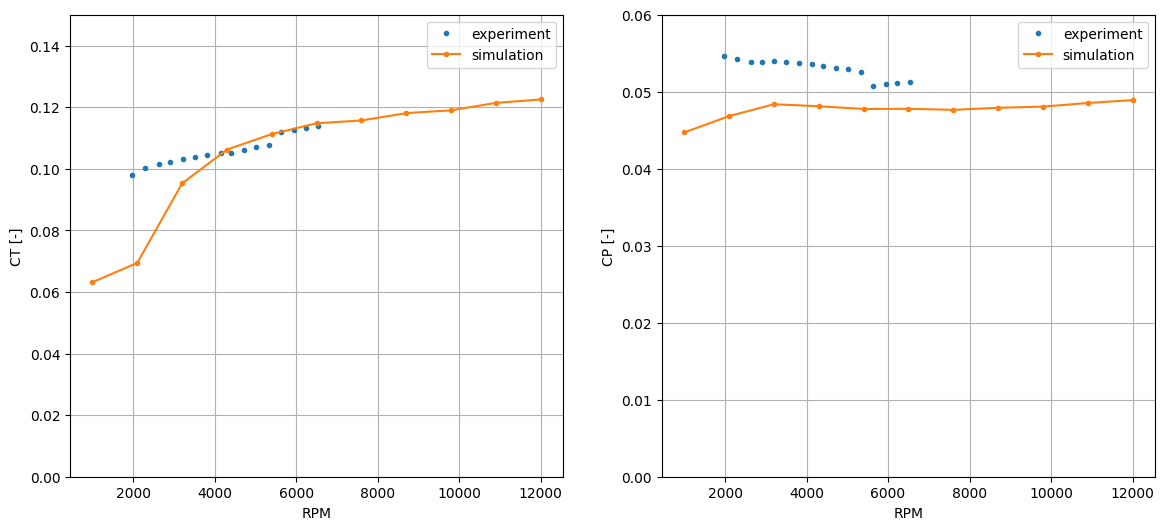

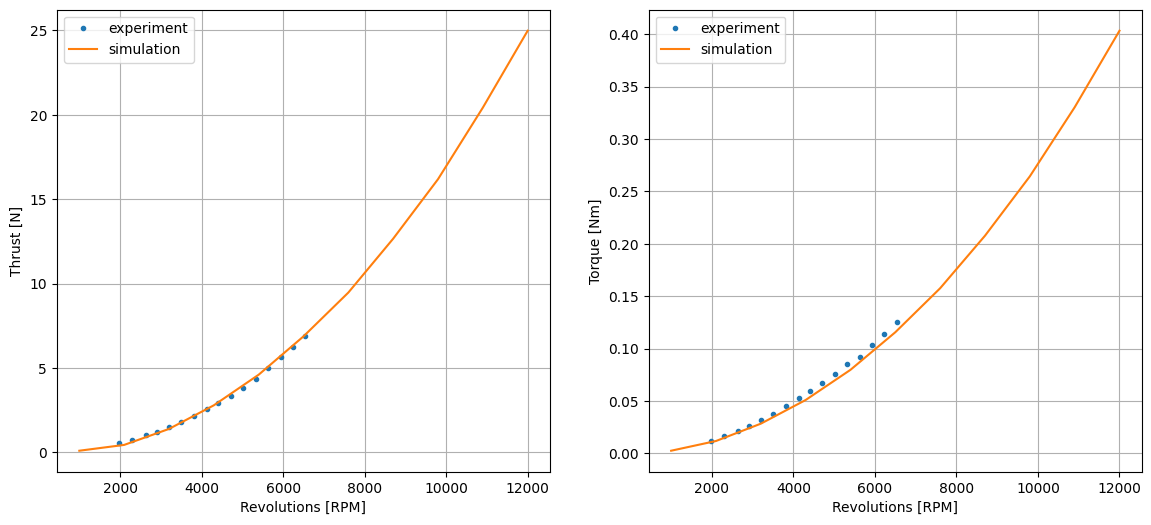

In [12]:
"""PLOT RPM SWEEP"""
%matplotlib inline
fig, axs = plt.subplots(1,2)
fig.set_figheight(6)
fig.set_figwidth(14)

axs[0].plot(propeller_experimental_data[f_name[0]]['RPM'], propeller_experimental_data[f_name[0]]['CT'], marker='.', label='experiment', linestyle='')
axs[0].plot(RPM_vec, Ct_simulation, marker='.', label='simulation')
axs[0].set_xlabel('RPM')
axs[0].set_ylabel('CT [-]')
axs[0].set_ylim([0, 0.15])
axs[0].grid(True)
axs[0].legend()

axs[1].plot(propeller_experimental_data[f_name[0]]['RPM'], propeller_experimental_data[f_name[0]]['CP'], marker='.', label='experiment', linestyle='')
axs[1].plot(RPM_vec, Cp_simulation, marker='.', label='simulation')
axs[1].set_xlabel('RPM')
axs[1].set_ylabel('CP [-]')
axs[1].set_ylim([0, 0.06])
axs[1].grid(True)
axs[1].legend()


fig1, axs1 = plt.subplots(1,2)
fig1.set_figheight(6)
fig1.set_figwidth(14)

thrust_experiment = 1.225 * propeller_experimental_data[f_name[0]]['CT'] * (propeller_experimental_data[f_name[0]]['RPM']/60)**2 * 0.254**4
torque_experiment = 1.225 * propeller_experimental_data[f_name[0]]['CP'] * (propeller_experimental_data[f_name[0]]['RPM']/60)**2 * 0.254**5 / (2*np.pi)

axs1[0].plot(propeller_experimental_data[f_name[0]]['RPM'], thrust_experiment, marker='.', label='experiment', linestyle='')
axs1[0].plot(RPM_vec, total_thrust_simulation, label='simulation')
axs1[0].set_xlabel('Revolutions [RPM]')
axs1[0].set_ylabel('Thrust [N]')
axs1[0].grid(True)
axs1[0].legend()

axs1[1].plot(propeller_experimental_data[f_name[0]]['RPM'], torque_experiment, marker='.', label='experiment', linestyle='')
axs1[1].plot(RPM_vec, total_torque_simulation, label='simulation')
axs1[1].set_xlabel('Revolutions [RPM]')
axs1[1].set_ylabel('Torque [Nm]')
axs1[1].grid(True)
axs1[1].legend()

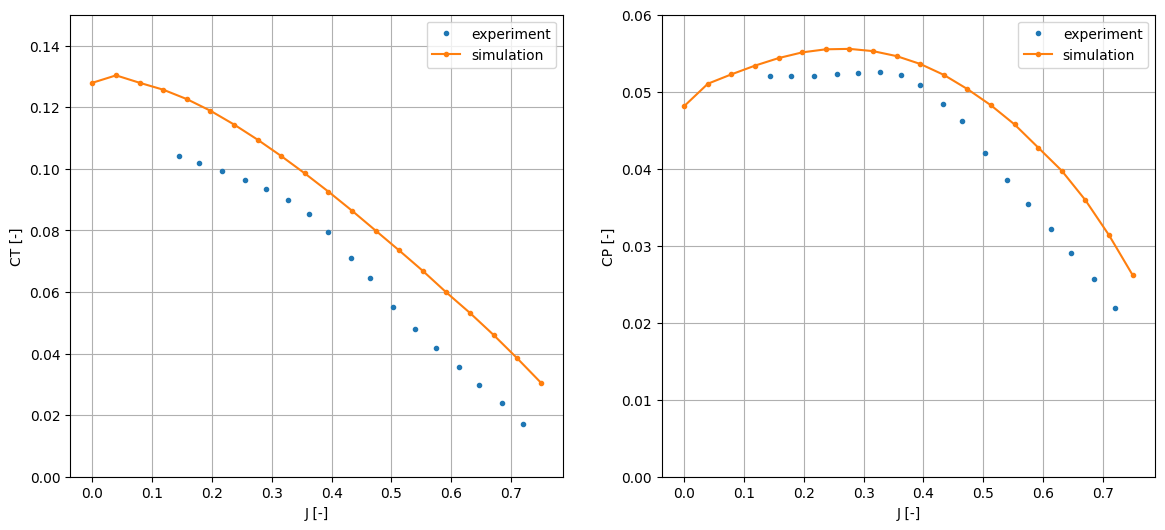

In [81]:
"""PLOT J SWEEP"""
%matplotlib inline
fig, axs = plt.subplots(1,2)
fig.set_figheight(6)
fig.set_figwidth(14)

axs[0].plot(propeller_experimental_data[f_name[0]]['J'], propeller_experimental_data[f_name[0]]['CT'], marker='.', label='experiment', linestyle='')
axs[0].plot(J_vec, Ct_simulation, marker='.', label='simulation')
axs[0].set_xlabel('J [-]')
axs[0].set_ylabel('CT [-]')
axs[0].set_ylim([0, 0.15])
axs[0].grid(True)
axs[0].legend()

axs[1].plot(propeller_experimental_data[f_name[0]]['J'], propeller_experimental_data[f_name[0]]['CP'], marker='.', label='experiment', linestyle='')
axs[1].plot(J_vec, Cp_simulation, marker='.', label='simulation')
axs[1].set_xlabel('J [-]')
axs[1].set_ylabel('CP [-]')
axs[1].set_ylim([0, 0.06])
axs[1].grid(True)
axs[1].legend()
